# **Instructor Effectiveness Modeling (EdTech Context)**

## Part 2: Data Interpretation and EDA

Classifying the columns, interpreting each metric, and visual analysis: distributions, outliers, correlations, and instructor/course-level effectiveness.

**Notebooks in this project:**

1. `01_Data_Ingestion_and_Preparation.ipynb`
2. `02_Data_Interpretation_and_EDA.ipynb` &nbsp;&larr; *you are here*
3. `03_Instructor_Level_Aggregation.ipynb`
4. `04_Machine_Learning_Model.ipynb`
5. `05_Model_Evaluation.ipynb`
6. `06_Interpretation_and_Analysis_Questions.ipynb`

---

---

# Part 2: Data Interpretation

---

In [85]:
# Importing libraies:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
data = pd.read_csv(r'C:\Users\acer\Desktop\Programs\Accredian-Assignment\data\instructor_effectiveness_dataset_2000_rows - instructor_effectiveness_dataset_2000_rows.csv.csv')  # Load the dataset

In [87]:
data.columns.to_list()  # List the column names in the dataset

['batch_id',
 'instructor_id',
 'course_id',
 'completion_rate',
 'avg_score_improvement',
 'avg_quiz_score',
 'dropout_rate',
 'avg_watch_time',
 'assignment_submission_rate',
 'forum_activity_rate',
 'avg_feedback_score',
 'feedback_response_rate']

In [88]:
data.info()  # Get a concise summary of the dataset, including data types and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   str    
 1   instructor_id               2000 non-null   str    
 2   course_id                   2000 non-null   str    
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), str(3)
memory usage: 187.6 KB



# **Our columns are classifies as:**

* 'batch_id',
*  'instructor_id',
* 'course_id',
* 'completion_rate',
* 'avg_score_improvement',
* 'avg_quiz_score',
* 'dropout_rate',
* 'avg_watch_time',
* 'assignment_submission_rate',
* 'forum_activity_rate',
* 'avg_feedback_score',
* 'feedback_response_rate'

# Here: I'm cosidering some columns as:

# **1.Indetifier_columns:**


**batch_id: It is an Unique identifier for each batch/row record.**
* Type: string
* Unique values: 2000(all unique, no null values)

**instructor_id: Identifier for the instructor teaching the batch**
* Type: string
* Unique values: 120 unique with repeation because instructors are in the organization according to the data.
* Duplications are so obvious to be expected.

**course_id:Identifier for the course being taught.**
* Type: string
* Unique values: 25 unique values means 25 cources are being taught with their possible weights.

# **Outcome/Performance Metrices:**

**completion_rate: Fraction of students who completed the course/batch**

* Type: Float(Numeric)
* Unique values: 1893
* range: 0.30 to 0.98 
* mean : 0.603	


**avg_score_improvement: Average improvement in student scores (likely percentage points)**

* Type: Numeric (float)
* Unique values: 1966
* Range: 6.16 – 40.00
* Mean: 27.036

**avg_quiz_score:Average quiz score of students in the batch**

* Type: Numeric (float)
* Unique : 1964
* Range: 40.39 – 100.0
* Mean : 77.956

**dropout_rate: Fraction of students who dropped out**
* Type: Numeric (float)
* Unique values: 1907
* Range : 0.02 – 0.70
* Mean: 0.395

# **Engagement Metrics:**

**avg_watch_time: Average video/content watch time (as a proportion)**
* Type: Numeric (float)
* Unique values: 1852
* range : 0.29 – 1.00
* Mean: 0.777

**assignment_submission_rate: Fraction of assignments submitted by students**
* Type: Numeric (float)
* Unique values: 1876
* Range: 0.25 – 1.00
* Mean: 0.753

**forum_activity_rate: Rate of student participation in discussion forums**
* Type: Numeric (float)
* Unique values: 1987
* Range: 0.00 – 0.64
* Mean: 0.250

# **Satisfaction Metrics:**

**avg_feedback_score: Average feedback/rating score given by students (scale ~1-5)**
* Type: Numeric (float)
* Unique values: 1934
* Range: 2.64 – 5.00
* Mean: 4.207

**feedback_response_rate: Fraction of students who responded to feedback surveys**
* Type: Numeric (float)
* Unique values: 1907
* Range: 0.26 – 1.00
* Mean: 0.737

# **Visual Analysis**

Now that each column has been interpreted individually, let's visualize the distributions and relationships to confirm (or challenge) the interpretations above.

In [89]:
# Customising some things:
sns.set_style('whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.dpi'] = 100

numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_cols

['completion_rate',
 'avg_score_improvement',
 'avg_quiz_score',
 'dropout_rate',
 'avg_watch_time',
 'assignment_submission_rate',
 'forum_activity_rate',
 'avg_feedback_score',
 'feedback_response_rate']

## **1. Univariate Distributions**

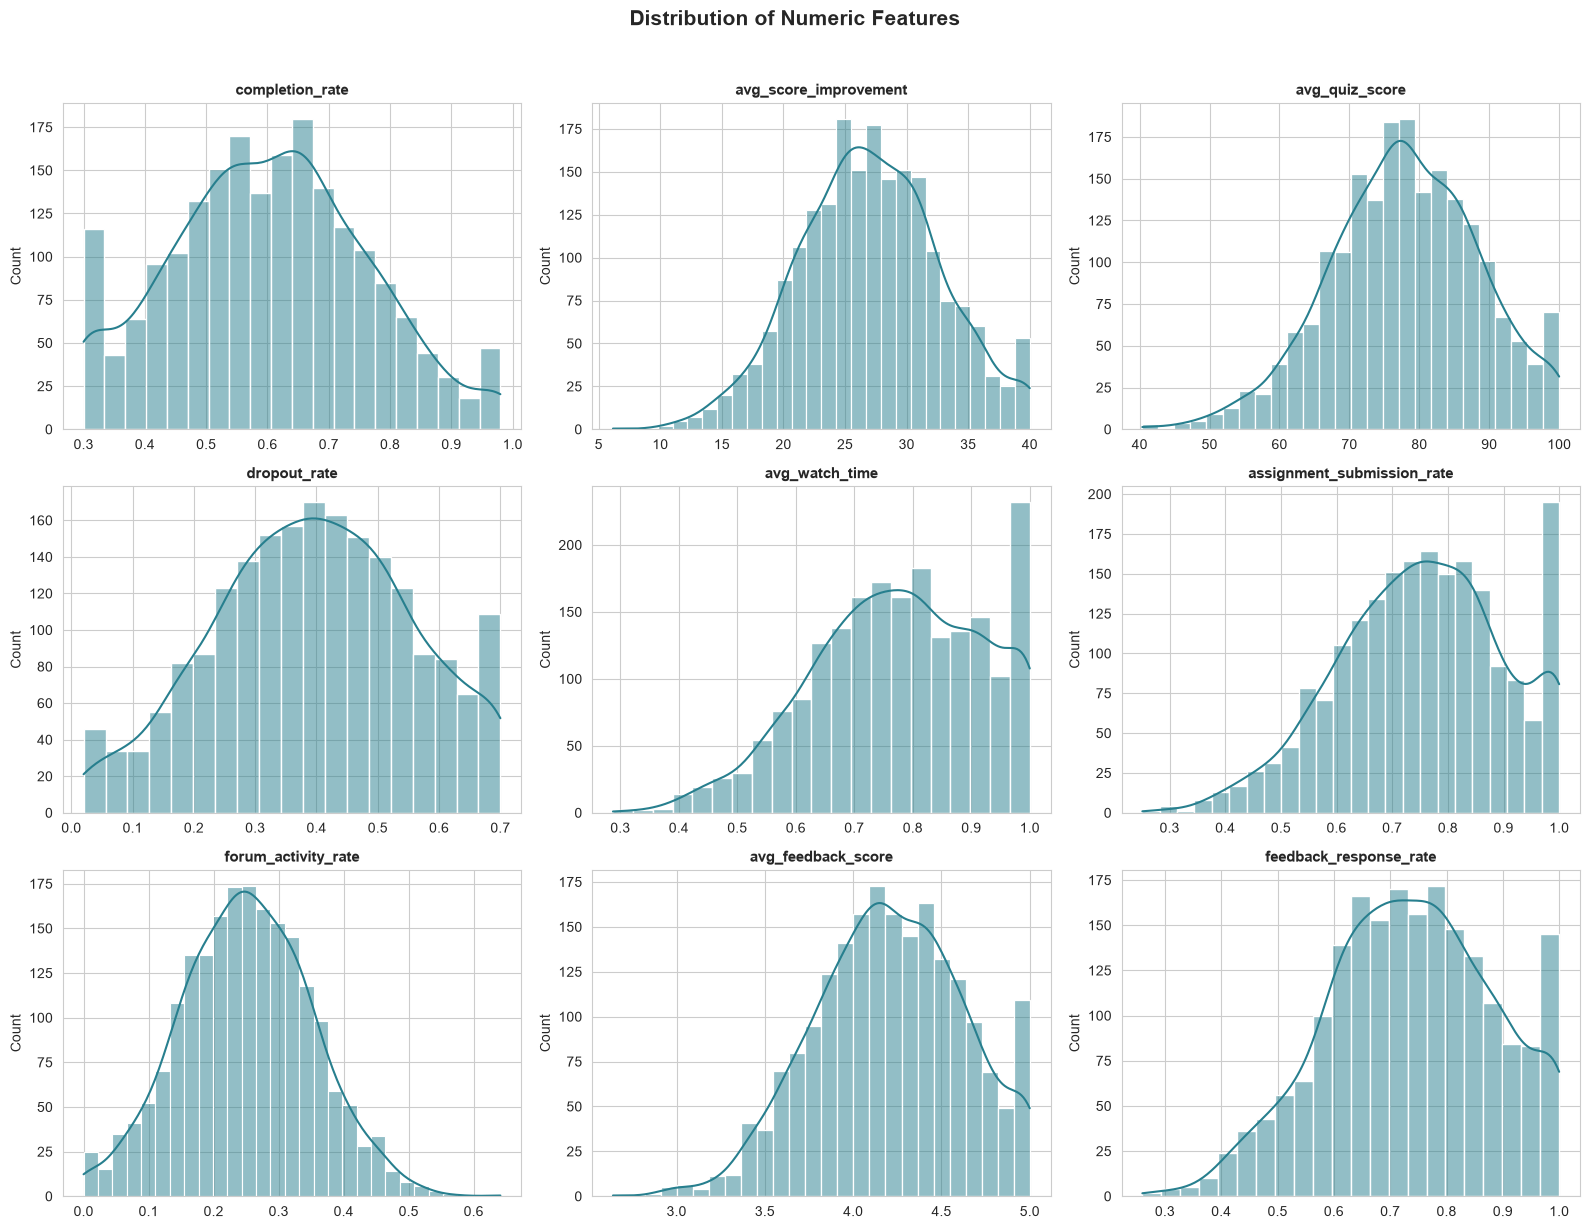

In [90]:
# Histogram + KDE for every numeric column, in a single grid instead of 9 separate cells
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(data=data, x=col, kde=True, ax=axes[i], color=sns.color_palette('viridis')[2])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Numeric Features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Note:** Most metrics (`completion_rate`, `dropout_rate`, `avg_quiz_score`, `avg_score_improvement`) are close to symmetric/normal. `forum_activity_rate` is right-skewed and concentrated near lower values, confirming it as the weakest engagement signal. `avg_feedback_score` is left-skewed toward high values, typical of subjective satisfaction ratings.

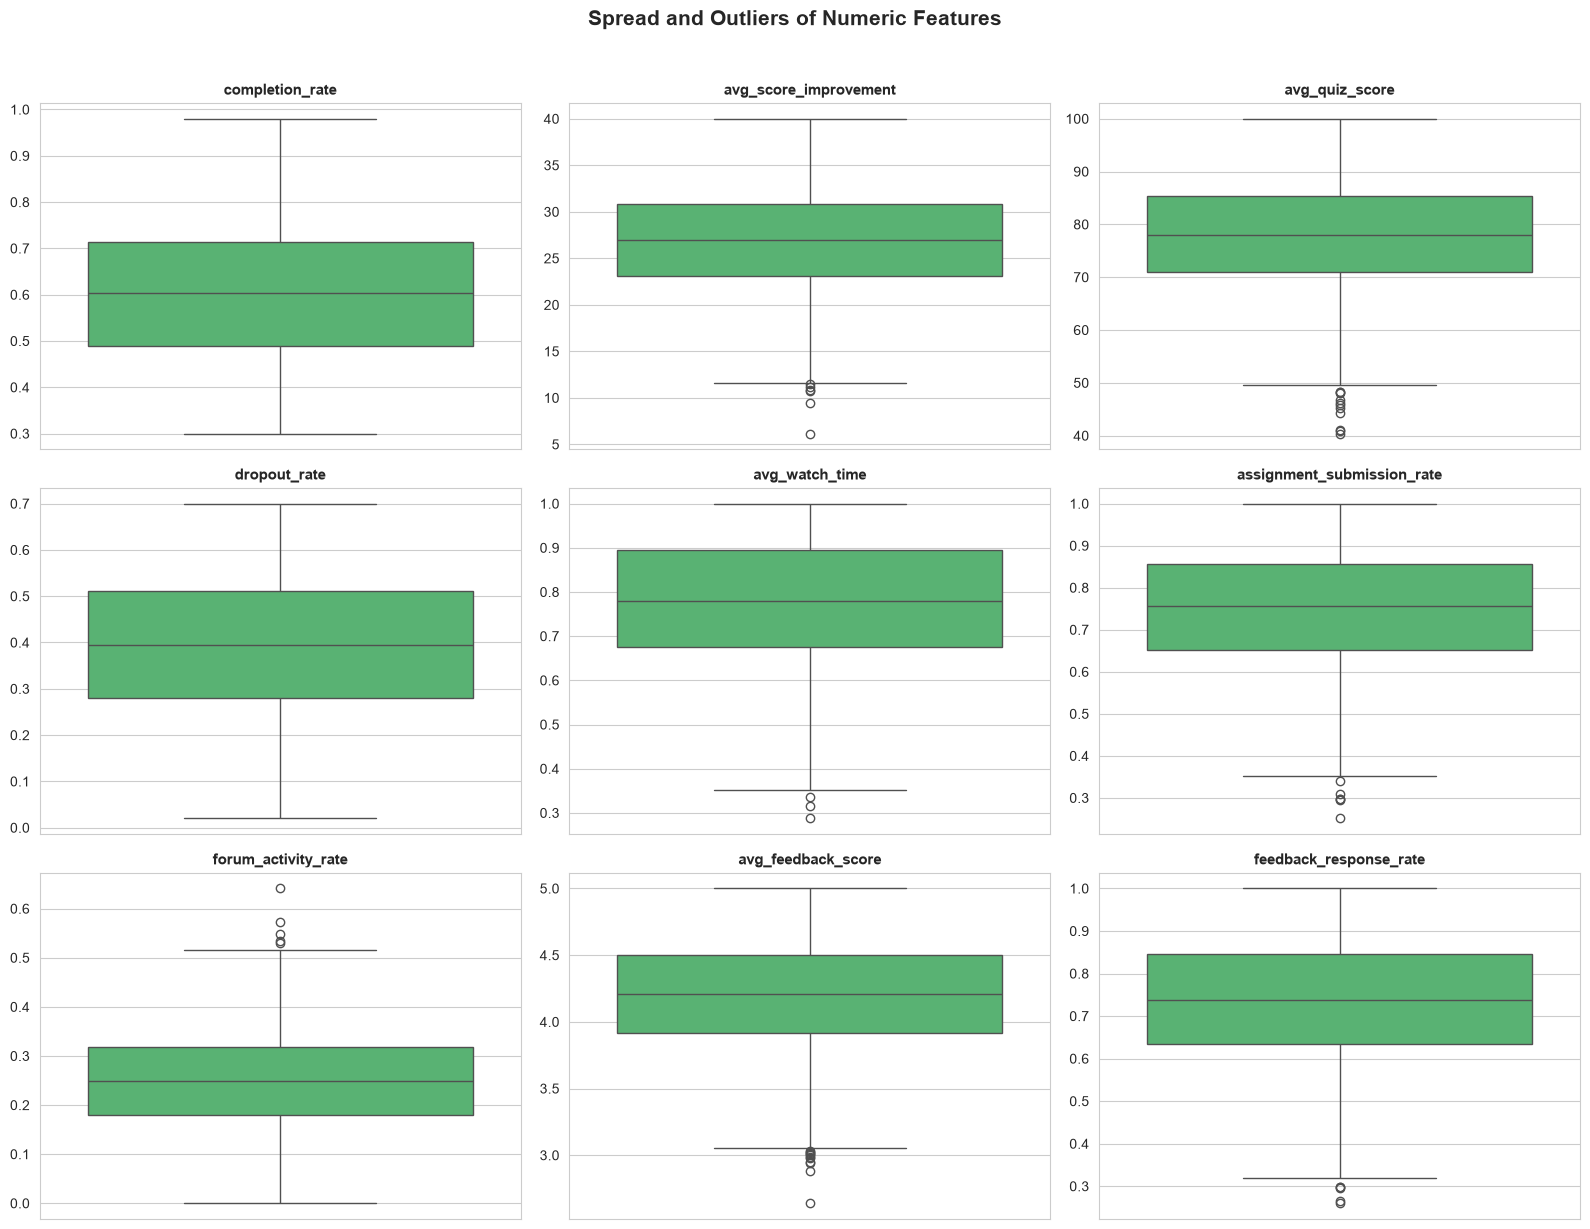

In [91]:
# Boxplots to spot outliers and compare spread across metrics
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=data, y=col, ax=axes[i], color=sns.color_palette('viridis')[4])
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('')

plt.suptitle('Spread and Outliers of Numeric Features', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Note:** No extreme outliers across most metrics — values stay within a reasonable IQR band, which matches the earlier observation that all metrics look like bounded/engineered rates or scores rather than raw unbounded measurements.

## **2. Correlation Between Metrics**

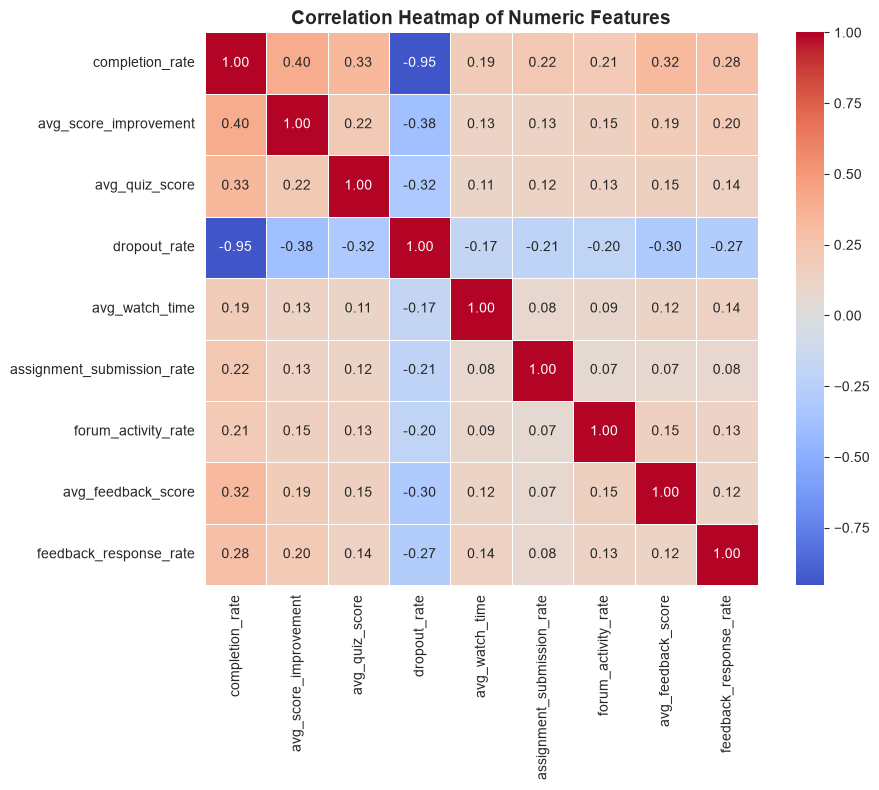

In [92]:
plt.figure(figsize=(10, 8))
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Note:** As expected, `completion_rate` and `dropout_rate` show a strong negative correlation. Engagement metrics (`avg_watch_time`, `assignment_submission_rate`) correlate positively with `completion_rate` and `avg_quiz_score`, supporting the idea that engagement drives outcomes. `forum_activity_rate` shows the weakest correlation with outcomes, reinforcing it as a softer signal.

## **3. Key Relationships (Bivariate)**

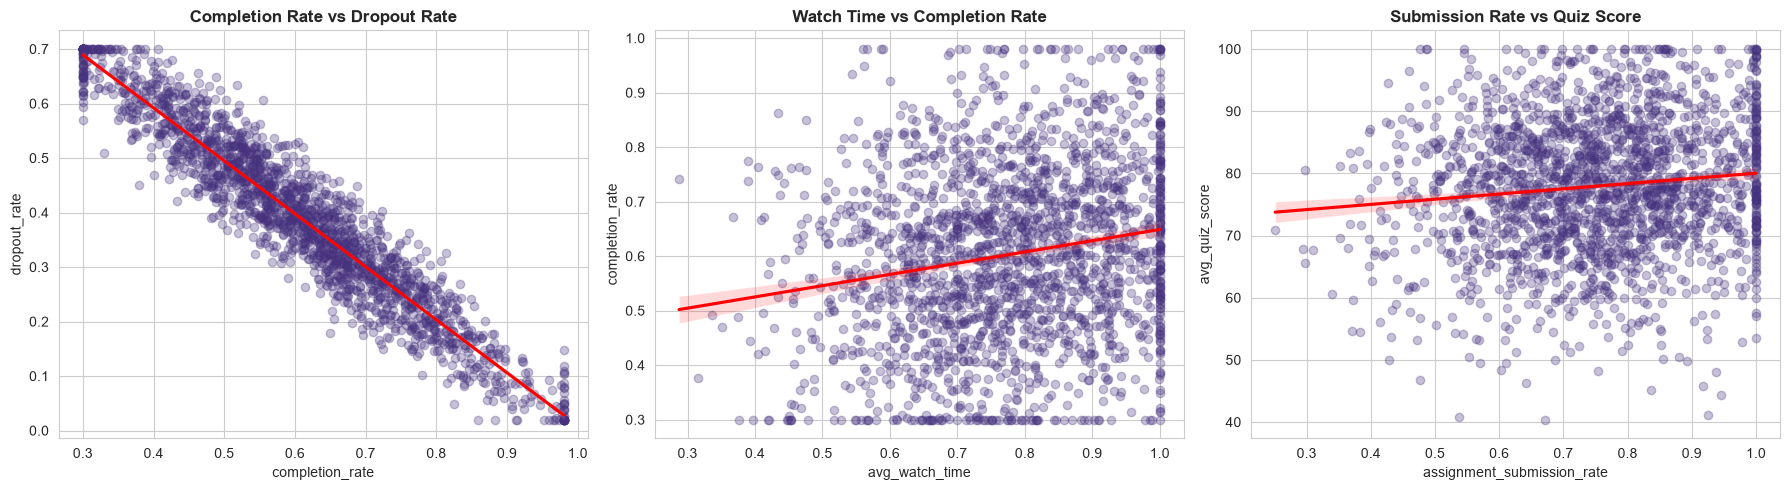

In [93]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(data=data, x='completion_rate', y='dropout_rate', ax=axes[0],
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[0].set_title('Completion Rate vs Dropout Rate', fontweight='bold')

sns.regplot(data=data, x='avg_watch_time', y='completion_rate', ax=axes[1],
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[1].set_title('Watch Time vs Completion Rate', fontweight='bold')

sns.regplot(data=data, x='assignment_submission_rate', y='avg_quiz_score', ax=axes[2],
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes[2].set_title('Submission Rate vs Quiz Score', fontweight='bold')

plt.tight_layout()
plt.show()

**Takeaway:** The trend lines confirm the heatmap: higher completion strongly predicts lower dropout, more watch time trends toward higher completion, and higher assignment submission trends toward higher quiz scores — together these suggest engagement metrics are useful leading indicators of outcome metrics.

## How Many Batches Does Each Instructor Teach?

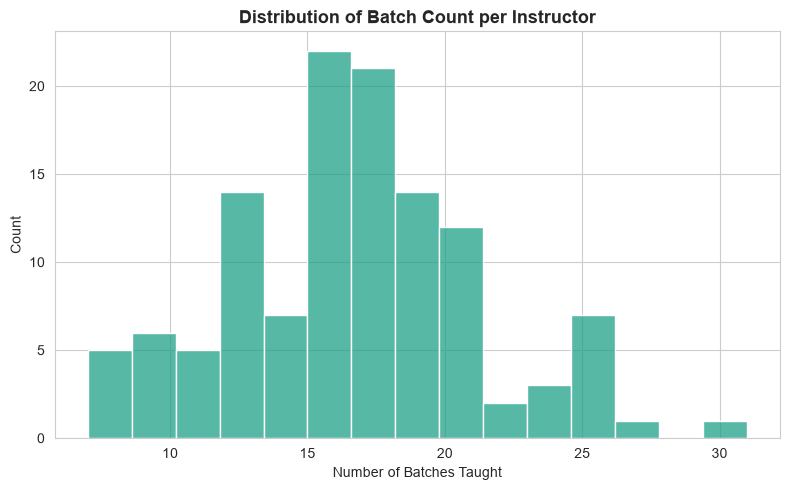

count    120.000000
mean      16.666667
std        4.582270
min        7.000000
25%       13.750000
50%       17.000000
75%       19.000000
max       31.000000
dtype: float64

In [94]:
batch_counts = data.groupby('instructor_id').size()
plt.figure(figsize=(8, 5))
sns.histplot(batch_counts, bins=15, color=sns.color_palette('viridis')[3])
plt.title('Distribution of Batch Count per Instructor', fontsize=13, fontweight='bold')
plt.xlabel('Number of Batches Taught')
plt.tight_layout()
plt.show()
batch_counts.describe()

**Observation:** Every instructor has taught **at least 7 batches** (median ~17, max 31), so there are no instructors with only 1–2 batches in this dataset. This matters for Step 3 — with a minimum of 7 batches per instructor, a simple mean aggregation is statistically reasonable for everyone; we don't need to drop or specially flag any instructor for having too little data.

## **4. Instructor-Level Effectiveness**

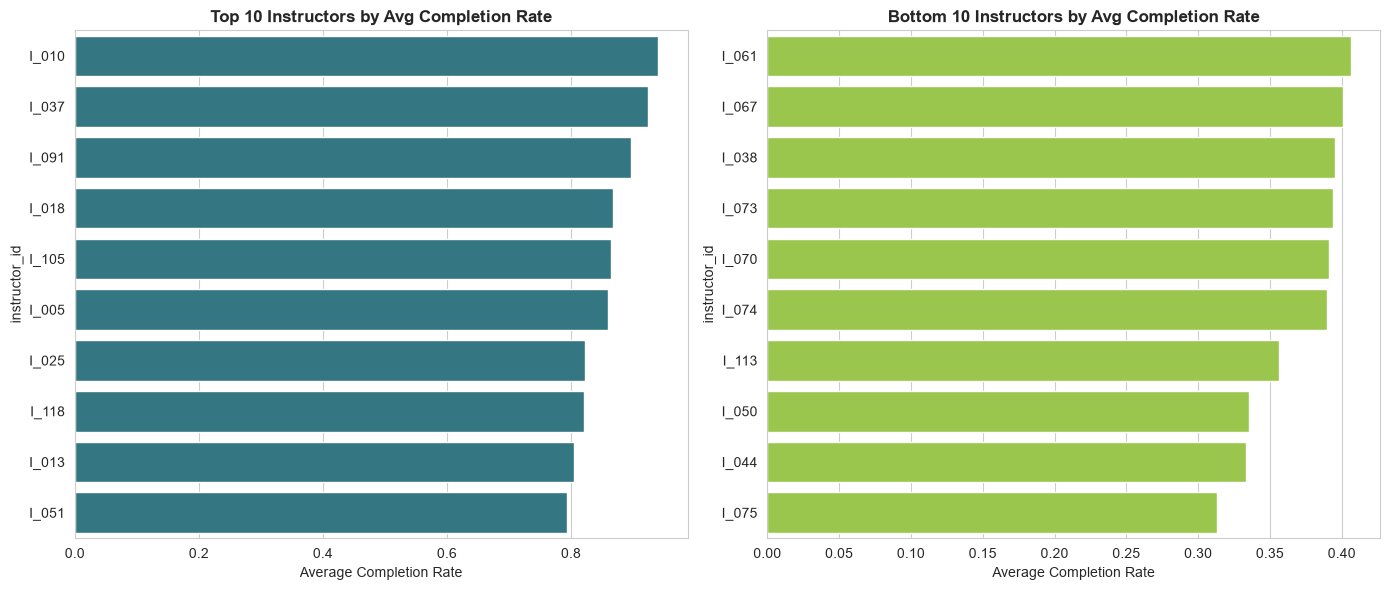

In [95]:
instructor_perf = data.groupby('instructor_id')[['completion_rate', 'dropout_rate', 'avg_quiz_score', 'avg_feedback_score']].mean()
instructor_perf_sorted = instructor_perf.sort_values('completion_rate', ascending=False)

top10 = instructor_perf_sorted.head(10)
bottom10 = instructor_perf_sorted.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=top10['completion_rate'], y=top10.index, ax=axes[0], color=sns.color_palette('viridis')[2])
axes[0].set_title('Top 10 Instructors by Avg Completion Rate', fontweight='bold')
axes[0].set_xlabel('Average Completion Rate')

sns.barplot(x=bottom10['completion_rate'], y=bottom10.index, ax=axes[1], color=sns.color_palette('viridis')[5])
axes[1].set_title('Bottom 10 Instructors by Avg Completion Rate', fontweight='bold')
axes[1].set_xlabel('Average Completion Rate')

plt.tight_layout()
plt.show()

**Note:** Aggregating per instructor (rather than looking at raw batch rows) surfaces a clear effectiveness gap between the top and bottom 10 instructors, making this a useful view for identifying who may need support or could mentor others.

## **5. Course-Level Effectiveness**

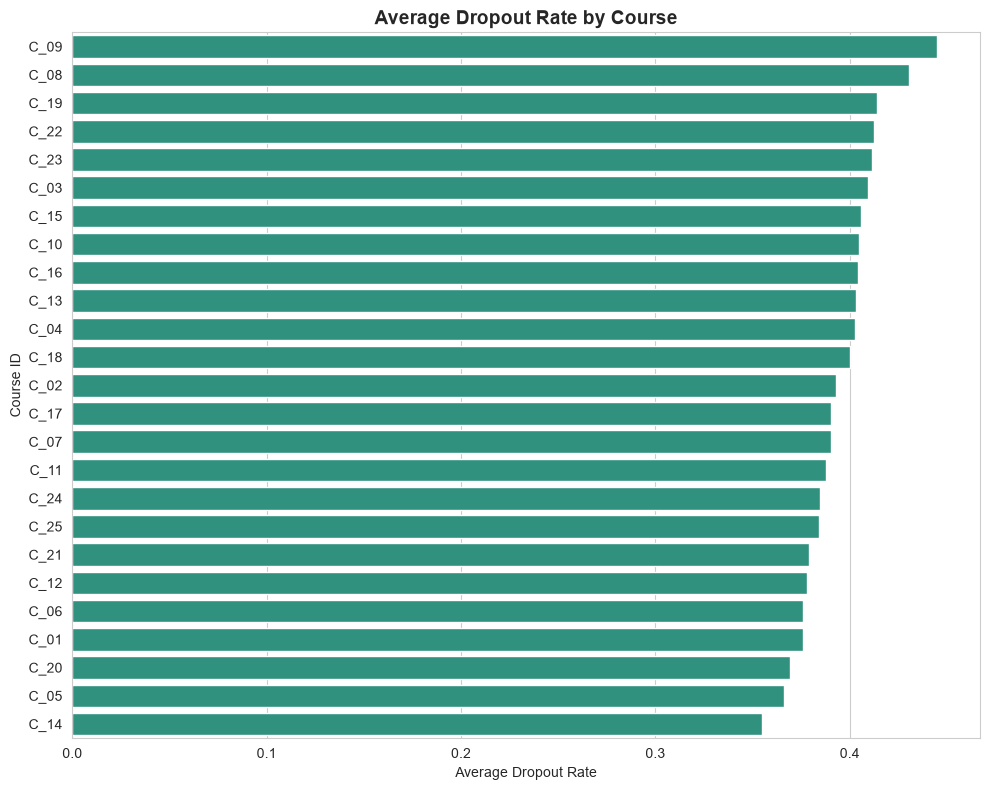

In [96]:
course_perf = data.groupby('course_id')['dropout_rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=course_perf.values, y=course_perf.index, color=sns.color_palette('viridis')[3])
plt.title('Average Dropout Rate by Course', fontsize=14, fontweight='bold')
plt.xlabel('Average Dropout Rate')
plt.ylabel('Course ID')
plt.tight_layout()
plt.show()

**Takeaway:** Dropout rate varies meaningfully by course, which suggests course content/difficulty plays a role alongside instructor effectiveness — worth controlling for `course_id` when evaluating instructors, so a tough course doesn't unfairly penalize a good instructor's dropout numbers.

### **EDA Summary**
* No missing values, no duplicate rows.
* Outcome metrics (completion, dropout, quiz score) and engagement metrics (watch time, submissions) move together as expected.
* Feedback-based metrics are more skewed and weakly correlated with the rest — they capture a different (subjective) dimension of effectiveness.
* Every instructor has enough batches (≥7) for a reliable instructor-level average.